In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
url = '../data/raw/diamonds.csv'
data = pd.read_csv(url, sep=',')

data.head(10)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [ ]:
data.shape 

(53940, 11)

In [53]:
data.columns.tolist()

['Unnamed: 0',
 'carat',
 'cut',
 'color',
 'clarity',
 'depth',
 'table',
 'price',
 'x',
 'y',
 'z']

In [54]:
data['Unnamed: 0'].duplicated().sum() 

np.int64(0)

In [24]:
data.duplicated().sum()

np.int64(0)

In [55]:
data.isnull().mean().round(4)

Unnamed: 0    0.0
carat         0.0
cut           0.0
color         0.0
clarity       0.0
depth         0.0
table         0.0
price         0.0
x             0.0
y             0.0
z             0.0
dtype: float64

In [56]:
data.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [57]:
zero_values = data[(data['x'] == 0) | (data['y'] == 0) | (data['z'] == 0)]
zero_values

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
2207,2208,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,2315,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,4792,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,5472,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,10168,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,11183,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,11964,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,13602,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,15952,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,24395,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


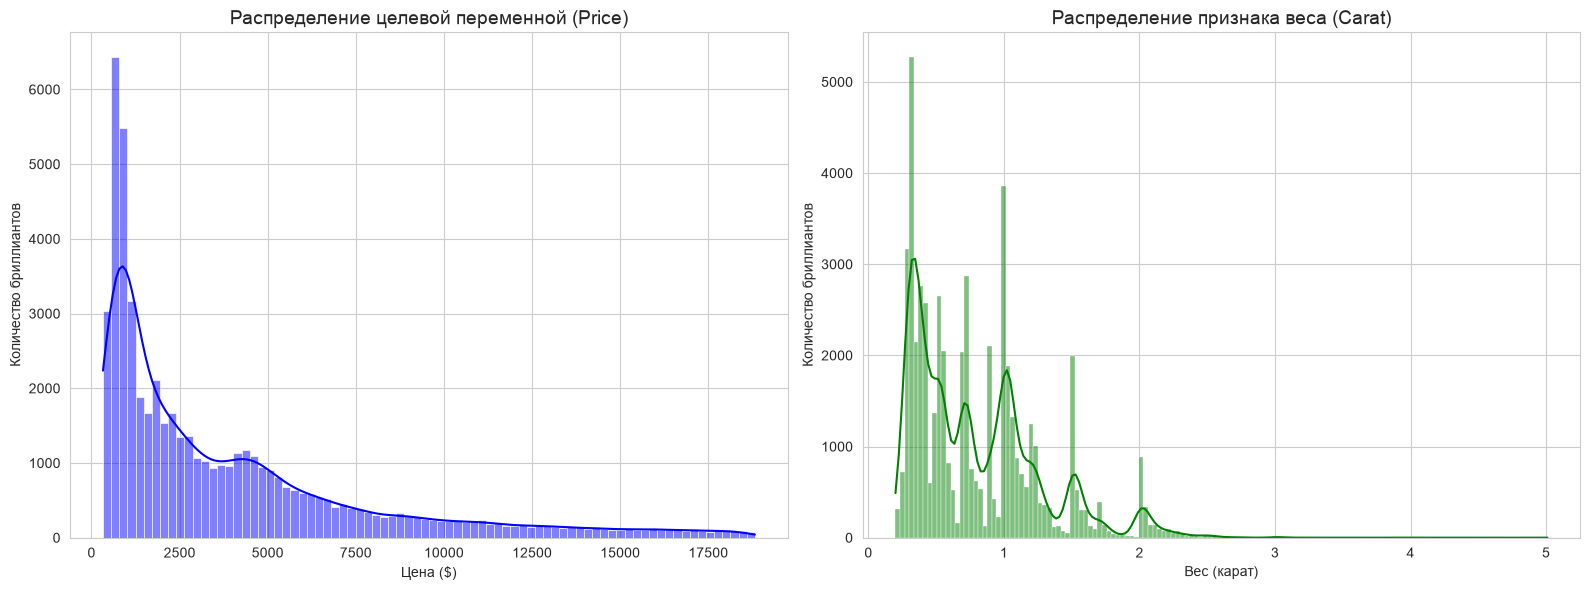

In [5]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. График распределения Цены (Target)
sns.histplot(data=data, x='price', kde=True, ax=axes[0], color='blue')
axes[0].set_title('Распределение целевой переменной (Price)', fontsize=14)
axes[0].set_xlabel('Цена ($)')
axes[0].set_ylabel('Количество бриллиантов')

# 2. График распределения Веса (Carat)
sns.histplot(data=data, x='carat', kde=True, ax=axes[1], color='green')
axes[1].set_title('Распределение признака веса (Carat)', fontsize=14)
axes[1].set_xlabel('Вес (карат)')
axes[1].set_ylabel('Количество бриллиантов')

plt.tight_layout()
plt.show()

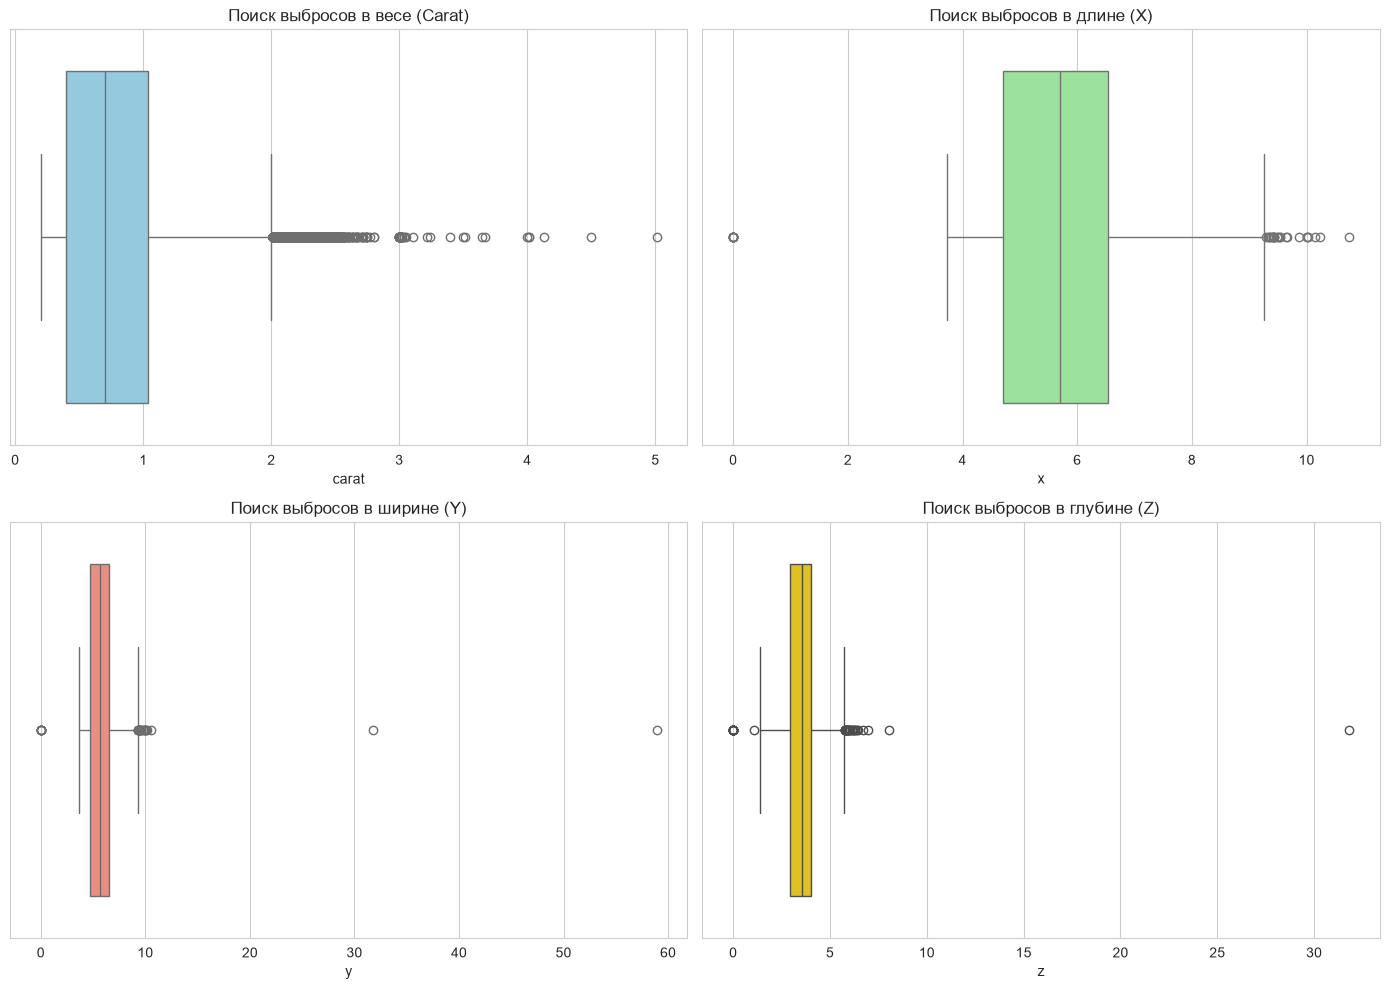

In [6]:
# Строим боксплоты для ключевых числовых фич
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=data, x='carat', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Поиск выбросов в весе (Carat)')

sns.boxplot(data=data, x='x', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Поиск выбросов в длине (X)')

sns.boxplot(data=data, x='y', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Поиск выбросов в ширине (Y)')

sns.boxplot(data=data, x='z', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Поиск выбросов в глубине (Z)')

plt.tight_layout()
plt.show()

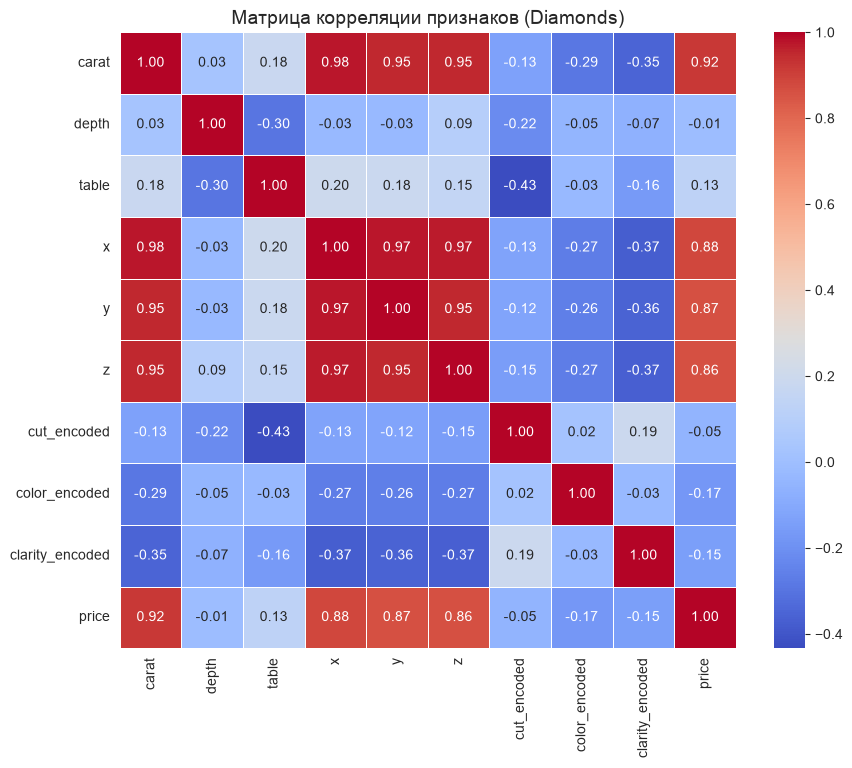

In [8]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

cut_mapping = {cat: i for i, cat in enumerate(cut_order)}
color_mapping = {cat: i for i, cat in enumerate(color_order)}
clarity_mapping = {cat: i for i, cat in enumerate(clarity_order)}

data['cut_encoded'] = data['cut'].map(cut_mapping)
data['color_encoded'] = data['color'].map(color_mapping)
data['clarity_encoded'] = data['clarity'].map(clarity_mapping)

# Нам нужны только числовые колонки для корреляции Пирсона
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_encoded', 'color_encoded', 'clarity_encoded', 'price']

# Считаем матрицу корреляций
corr_matrix = data[numeric_features].corr()

# Строим тепловую карту
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Матрица корреляции признаков (Diamonds)', fontsize=14)
plt.show()

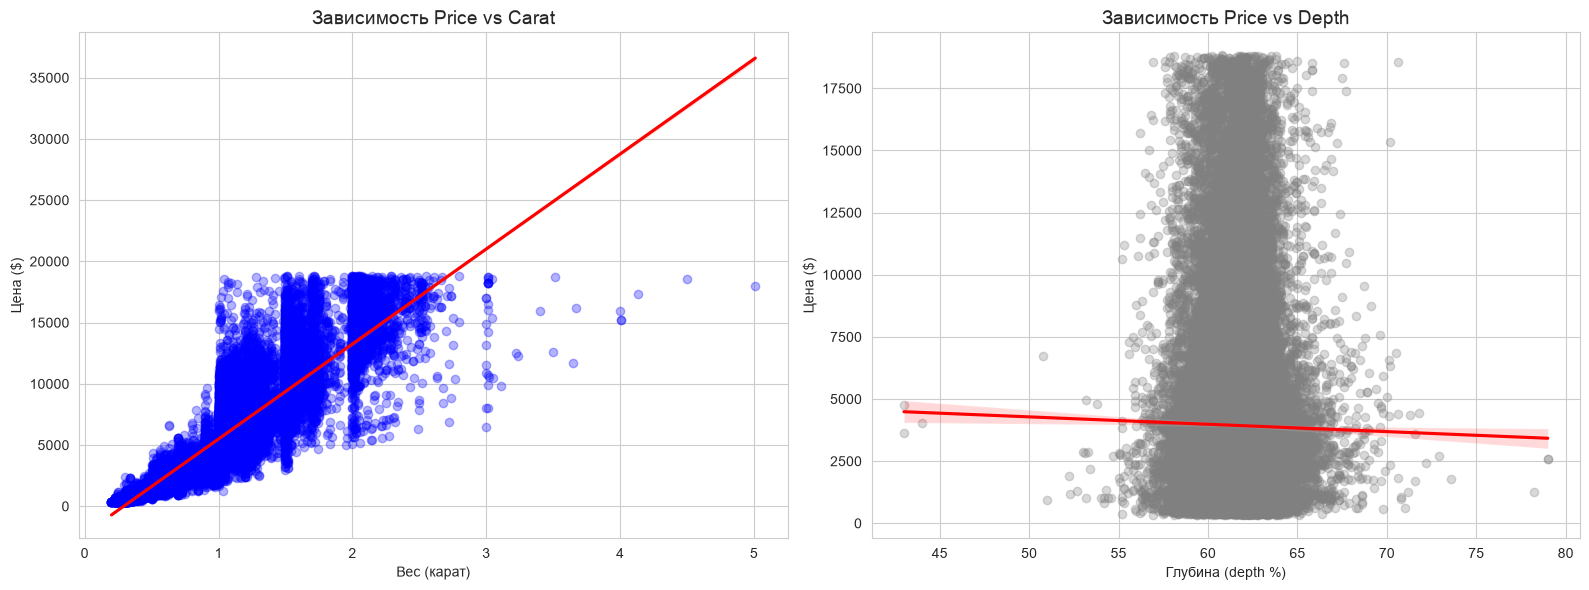

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Зависимость цены от Карата (Сильный признак)
sns.regplot(data=data, x='carat', y='price', ax=axes[0], 
            scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red'})
axes[0].set_title('Зависимость Price vs Carat', fontsize=14)
axes[0].set_xlabel('Вес (карат)')
axes[0].set_ylabel('Цена ($)')

# 2. Зависимость цены от Depth (Слабый признак)
sns.regplot(data=data, x='depth', y='price', ax=axes[1], 
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
axes[1].set_title('Зависимость Price vs Depth', fontsize=14)
axes[1].set_xlabel('Глубина (depth %)')
axes[1].set_ylabel('Цена ($)')



plt.tight_layout()
plt.show()

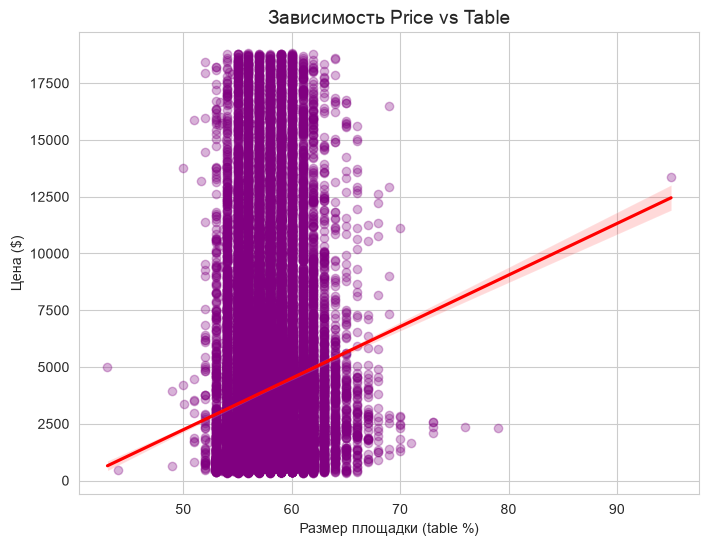

In [15]:
plt.figure(figsize=(8, 6))
# Строим график Цена vs Table
sns.regplot(data=data, x='table', y='price', 
            scatter_kws={'alpha':0.3, 'color':'purple'}, line_kws={'color':'red'})

plt.title('Зависимость Price vs Table', fontsize=14)
plt.xlabel('Размер площадки (table %)')
plt.ylabel('Цена ($)')
plt.show()

/var/folders/x8/6y8tr6zd7cb32xjdwv1j8hvc0000gn/T/ipykernel_1066/2202028916.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='cut', y='price', order=cut_order, ax=axes[0], palette='Blues')
/var/folders/x8/6y8tr6zd7cb32xjdwv1j8hvc0000gn/T/ipykernel_1066/2202028916.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(cut_order, rotation=45)
/var/folders/x8/6y8tr6zd7cb32xjdwv1j8hvc0000gn/T/ipykernel_1066/2202028916.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='color', y='price', order=color_order, ax=axes[1], palett

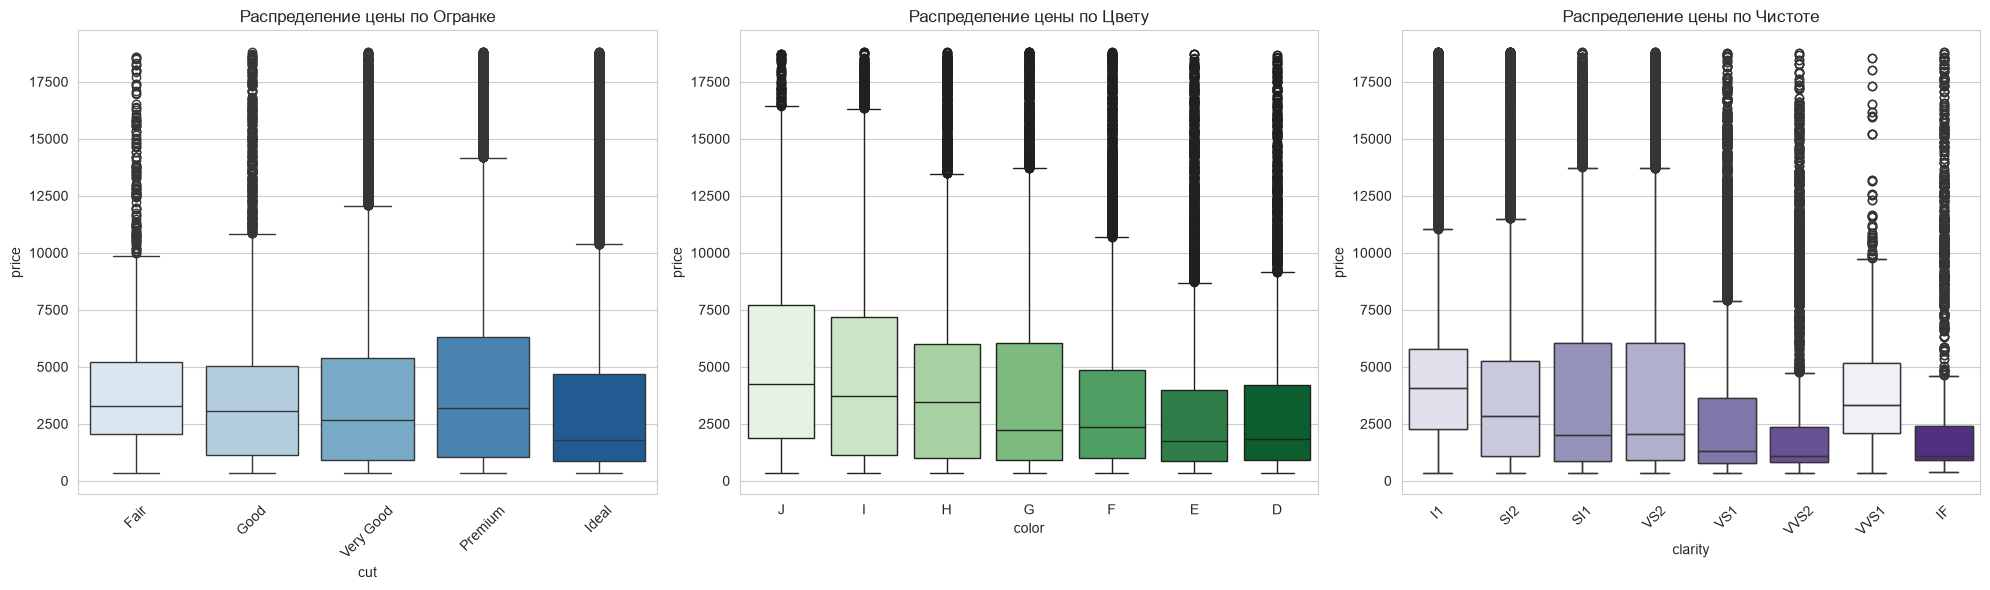

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Порядок категорий (от худшего к лучшему)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# 1. Цена vs Огранка (Cut)
sns.boxplot(data=data, x='cut', y='price', order=cut_order, ax=axes[0], palette='Blues')
axes[0].set_title('Распределение цены по Огранке', fontsize=12)
axes[0].set_xticklabels(cut_order, rotation=45)

# 2. Цена vs Цвет (Color)
sns.boxplot(data=data, x='color', y='price', order=color_order, ax=axes[1], palette='Greens')
axes[1].set_title('Распределение цены по Цвету', fontsize=12)

# 3. Цена vs Чистота (Clarity)
sns.boxplot(data=data, x='clarity', y='price', ax=axes[2], palette='Purples') # Ошибка в оригинальном коде: y='clarity_order' -> должно быть y='price', order=clarity_order
# Исправленная строчка для тебя:
sns.boxplot(data=data, x='clarity', y='price', order=clarity_order, ax=axes[2], palette='Purples')
axes[2].set_title('Распределение цены по Чистоте', fontsize=12)
axes[2].set_xticklabels(clarity_order, rotation=45)

plt.tight_layout()
plt.show()

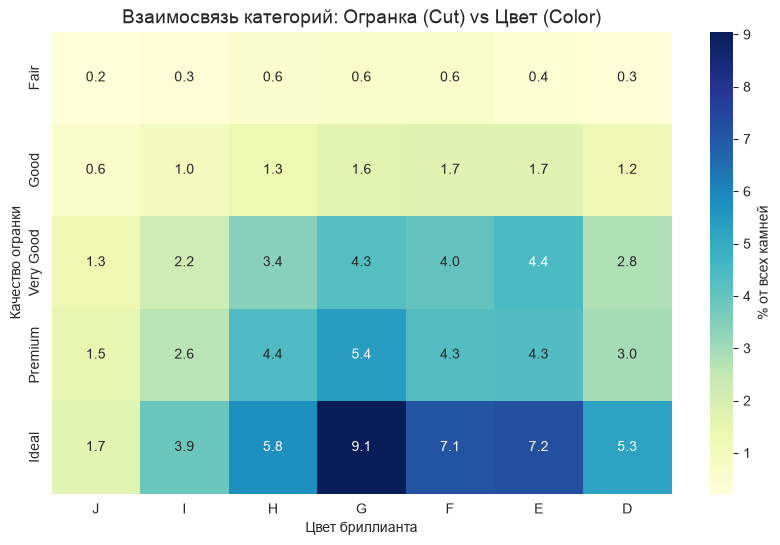

In [21]:
# 1. Строим таблицу сопряженности (в процентах от общего числа, чтобы нормировать данные)
pivot_table = pd.crosstab(
    data['cut'], data['color'], normalize='all'
) * 100

# Порядок для красивого отображения
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
pivot_table = pivot_table.reindex(index=cut_order, columns=color_order)

# 2. Визуализируем через тепловую карту
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap='YlGnBu',
    cbar_kws={'label': '% от всех камней'},
)
plt.title(
    'Взаимосвязь категорий: Огранка (Cut) vs Цвет (Color)', fontsize=14
)
plt.xlabel('Цвет бриллианта')
plt.ylabel('Качество огранки')
plt.show()

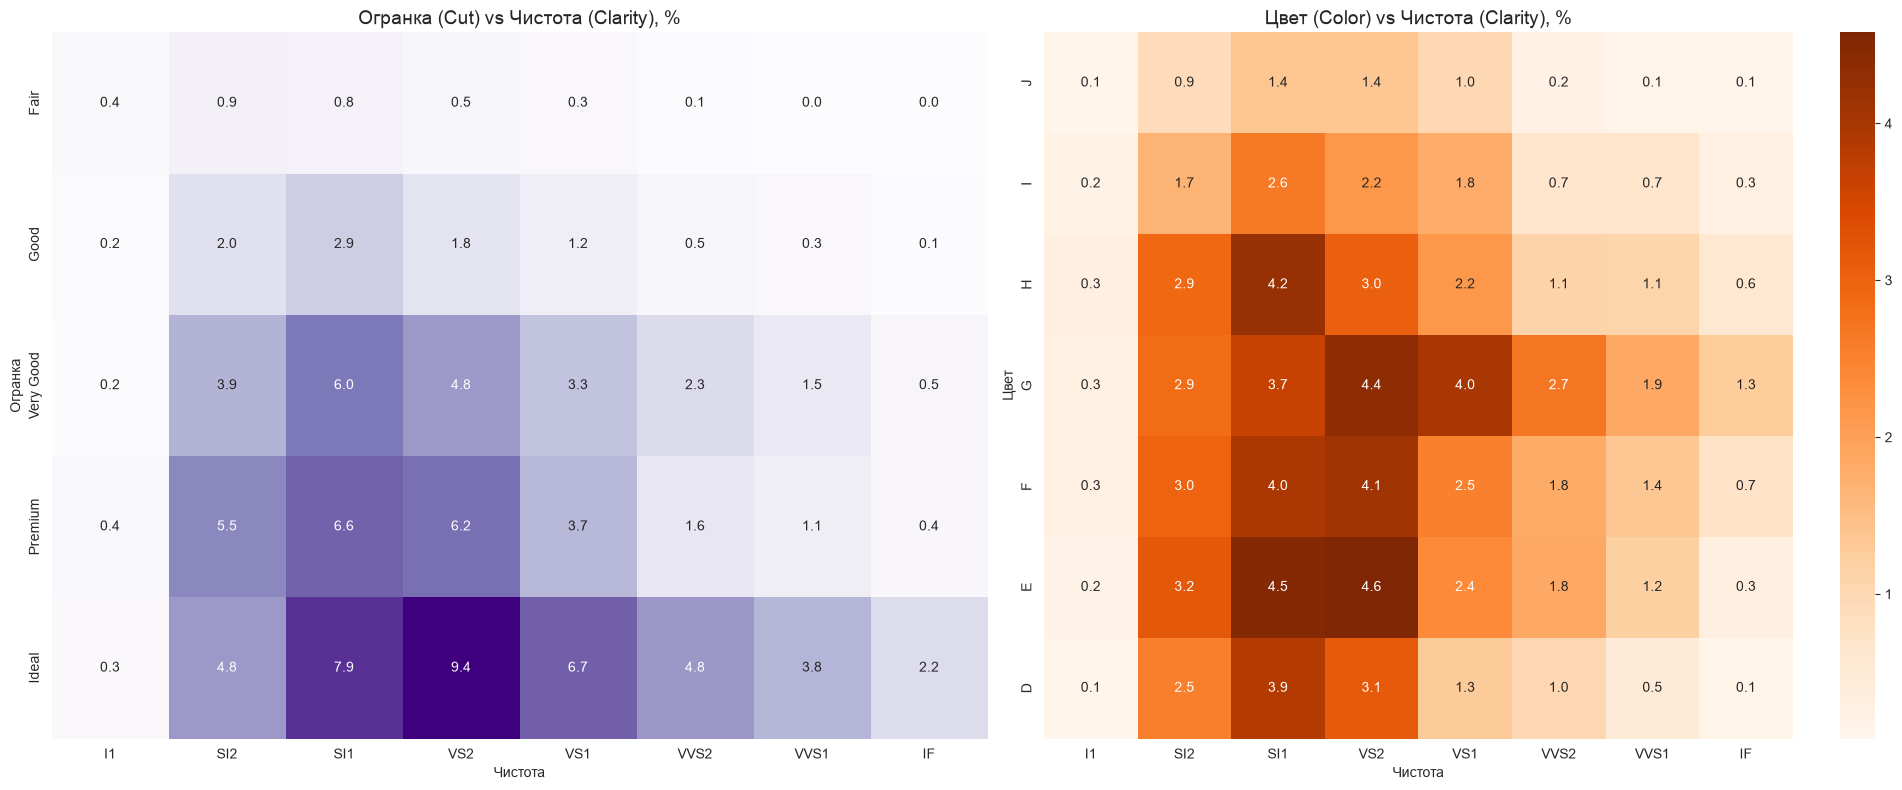

In [22]:
# Задаем правильный порядок для всех категорий
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Пара 1: Огранка (Cut) vs Чистота (Clarity)
pivot_cut_clarity = pd.crosstab(data['cut'], data['clarity'], normalize='all') * 100
pivot_cut_clarity = pivot_cut_clarity.reindex(index=cut_order, columns=clarity_order)

sns.heatmap(pivot_cut_clarity, annot=True, fmt=".1f", cmap='Purples', ax=axes[0], cbar=False)
axes[0].set_title('Огранка (Cut) vs Чистота (Clarity), %', fontsize=14)
axes[0].set_xlabel('Чистота')
axes[0].set_ylabel('Огранка')

# Пара 2: Цвет (Color) vs Чистота (Clarity)
pivot_color_clarity = pd.crosstab(data['color'], data['clarity'], normalize='all') * 100
pivot_color_clarity = pivot_color_clarity.reindex(index=color_order, columns=clarity_order)

sns.heatmap(pivot_color_clarity, annot=True, fmt=".1f", cmap='Oranges', ax=axes[1])
axes[1].set_title('Цвет (Color) vs Чистота (Clarity), %', fontsize=14)
axes[1].set_xlabel('Чистота')
axes[1].set_ylabel('Цвет')

plt.tight_layout()
plt.show()